In [1]:
import os, glob, re
import pandas as pd

BASE_DIR = '../input/Density_Scenarios_Paper'  # <- 修改路径

tif_files = sorted(glob.glob(os.path.join(BASE_DIR, '**/*.tif'), recursive=True))
print(f'Total tif files: {len(tif_files)}')
print()

# Print ALL tif basenames
for f in tif_files:
    print(os.path.relpath(f, BASE_DIR))

Total tif files: 1128

CA/Cameroun_low80_consdensity_2020.tif
CA/Cameroun_low80_consdensity_2025.tif
CA/Cameroun_low80_consdensity_2030.tif
CA/Cameroun_low80_consdensity_2035.tif
CA/Cameroun_low80_consdensity_2040.tif
CA/Cameroun_low80_consdensity_2045.tif
CA/Cameroun_low80_consdensity_2050.tif
CA/Cameroun_low80_highdensity_2020.tif
CA/Cameroun_low80_highdensity_2025.tif
CA/Cameroun_low80_highdensity_2030.tif
CA/Cameroun_low80_highdensity_2035.tif
CA/Cameroun_low80_highdensity_2040.tif
CA/Cameroun_low80_highdensity_2045.tif
CA/Cameroun_low80_highdensity_2050.tif
CA/Cameroun_low80_lowdensity_2020.tif
CA/Cameroun_low80_lowdensity_2025.tif
CA/Cameroun_low80_lowdensity_2030.tif
CA/Cameroun_low80_lowdensity_2035.tif
CA/Cameroun_low80_lowdensity_2040.tif
CA/Cameroun_low80_lowdensity_2045.tif
CA/Cameroun_low80_lowdensity_2050.tif
CA/Central_African_Republic_cons80_lowdensity_2020.tif
CA/Central_African_Republic_cons80_lowdensity_2025.tif
CA/Central_African_Republic_cons80_lowdensity_2030.tif


In [2]:
# Parse filename structure
# Example: Guinea_Ecuatorial_low80_highdensity_2050.tif
# Pattern: {country_name}_{something}_{scenario}_{year}.tif

records = []
for f in tif_files:
    name = os.path.splitext(os.path.basename(f))[0]
    folder = os.path.basename(os.path.dirname(f))
    
    # Extract year
    year_m = re.search(r'(\d{4})$', name)
    year = year_m.group(1) if year_m else None
    
    # Extract scenario keyword
    scenario = None
    for kw in ['highdensity', 'high_density', 'consdensity', 'cons_density', 
                'consolidated', 'lowdensity', 'low_density',
                'highdensit', 'consdensit', 'lowdensit']:
        if kw.lower() in name.lower():
            scenario = kw
            break
    
    # Extract any numeric part (like low80, low60...)
    num_m = re.search(r'(low|high|cons)(\d+)', name, re.IGNORECASE)
    num_suffix = num_m.group(0) if num_m else None
    
    records.append({
        'folder': folder,
        'basename': name,
        'year': year,
        'scenario': scenario,
        'num_suffix': num_suffix,
        'size_mb': os.path.getsize(f) / 1024 / 1024
    })

df = pd.DataFrame(records)
print('=== Scenario keyword counts ===')
print(df['scenario'].value_counts().to_string())
print()
print('=== Year counts ===')
print(df['year'].value_counts().to_string())
print()
print('=== Numeric suffix counts ===')
print(df['num_suffix'].value_counts().to_string())
print()
print('=== By folder ===')
print(df.groupby('folder')['scenario'].value_counts().to_string())

=== Scenario keyword counts ===
scenario
lowdensity     385
consdensity    372
highdensity    371

=== Year counts ===
year
2020    161
2025    161
2030    161
2035    161
2040    161
2045    161
2050    161
2026      1

=== Numeric suffix counts ===
num_suffix
low80     1122
cons80       6

=== By folder ===
folder   scenario   
CA       lowdensity     69
         consdensity    57
         highdensity    56
EA       consdensity    63
         highdensity    63
         lowdensity     63
Insular  consdensity    42
         highdensity    42
         lowdensity     42
NA       consdensity    35
         highdensity    35
         lowdensity     35
NIG      consdensity     7
         highdensity     7
         lowdensity      7
SA       consdensity    70
         highdensity    70
         lowdensity     70
WA       lowdensity     99
         consdensity    98
         highdensity    98


In [3]:
# Show all unique filename patterns (replace country name with placeholder)
# to find the template
print('=== Full basename sample (first 30) ===')
for r in records[:30]:
    print(f"  [{r['folder']}]  {r['basename']}  →  scenario={r['scenario']}  year={r['year']}")

=== Full basename sample (first 30) ===
  [CA]  Cameroun_low80_consdensity_2020  →  scenario=consdensity  year=2020
  [CA]  Cameroun_low80_consdensity_2025  →  scenario=consdensity  year=2025
  [CA]  Cameroun_low80_consdensity_2030  →  scenario=consdensity  year=2030
  [CA]  Cameroun_low80_consdensity_2035  →  scenario=consdensity  year=2035
  [CA]  Cameroun_low80_consdensity_2040  →  scenario=consdensity  year=2040
  [CA]  Cameroun_low80_consdensity_2045  →  scenario=consdensity  year=2045
  [CA]  Cameroun_low80_consdensity_2050  →  scenario=consdensity  year=2050
  [CA]  Cameroun_low80_highdensity_2020  →  scenario=highdensity  year=2020
  [CA]  Cameroun_low80_highdensity_2025  →  scenario=highdensity  year=2025
  [CA]  Cameroun_low80_highdensity_2030  →  scenario=highdensity  year=2030
  [CA]  Cameroun_low80_highdensity_2035  →  scenario=highdensity  year=2035
  [CA]  Cameroun_low80_highdensity_2040  →  scenario=highdensity  year=2040
  [CA]  Cameroun_low80_highdensity_2045  →  scen

In [4]:
# How many tifs per country folder?
# If 3 scenarios × years → each country should have 3 (or 6 if 2015+2050)
print('=== Files per folder ===')
folder_counts = df.groupby('folder').size().sort_values(ascending=False)
print(folder_counts.to_string())
print()

# Cross-tab: folder × scenario
print('=== Folder × Scenario cross-tab ===')
ct = pd.crosstab(df['folder'], df['scenario'])
print(ct.to_string())

=== Files per folder ===
folder
WA         295
SA         210
EA         189
CA         182
Insular    126
NA         105
NIG         21

=== Folder × Scenario cross-tab ===
scenario  consdensity  highdensity  lowdensity
folder                                        
CA                 57           56          69
EA                 63           63          63
Insular            42           42          42
NA                 35           35          35
NIG                 7            7           7
SA                 70           70          70
WA                 98           98          99


In [5]:
# Read one tif with rasterio to understand its content
try:
    import rasterio
    from rasterio.plot import show
    import matplotlib.pyplot as plt
    import numpy as np

    # Pick one file per scenario type
    for scenario_kw in ['highdensity', 'consdensity', 'lowdensity', 
                         'highdensit', 'consdensit', 'lowdensit']:
        matches = [f for f in tif_files if scenario_kw.lower() in f.lower()]
        if matches:
            sample = matches[0]
            with rasterio.open(sample) as src:
                meta = src.meta
                bounds = src.bounds
                data = src.read(1)
                nodata = src.nodata
                valid = data[data != nodata] if nodata is not None else data.flatten()
                unique_vals = np.unique(valid)
            print(f"--- Scenario: {scenario_kw} ---")
            print(f"File: {os.path.basename(sample)}")
            print(f"CRS: {meta['crs']}")
            print(f"Shape: {meta['height']} × {meta['width']}")
            print(f"Bounds: {bounds}")
            print(f"Dtype: {meta['dtype']}")
            print(f"NoData: {nodata}")
            print(f"Unique values ({len(unique_vals)} total): {unique_vals[:20]}")
            print()
            break  # just one for now

except ImportError:
    print('rasterio not installed — run: pip install rasterio')
    print('Checking with gdal instead...')
    import subprocess
    sample = tif_files[0]
    result = subprocess.run(['gdalinfo', sample], capture_output=True, text=True)
    print(result.stdout[:2000])

--- Scenario: highdensity ---
File: Cameroun_low80_highdensity_2020.tif
CRS: EPSG:4326
Shape: 3427 × 2306
Bounds: BoundingBox(left=8.501530279946998, bottom=1.6531935636923976, right=16.188196945845, top=13.0765268969115)
Dtype: float32
NoData: -3.3999999521443642e+38
Unique values (509 total): [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]



In [6]:
# Compare HIGH vs CONS vs LOW for the same country/city
# Find a country that has all 3 scenarios
import rasterio
import numpy as np

scenario_map = {}
for f in tif_files:
    name = os.path.basename(f).lower()
    folder = os.path.basename(os.path.dirname(f))
    for kw in ['highdensity','highdensit','high_density']:
        if kw in name: scenario_map.setdefault(folder, {})['high'] = f
    for kw in ['consdensity','consdensit','cons_density','consolidated']:
        if kw in name: scenario_map.setdefault(folder, {})['cons'] = f
    for kw in ['lowdensity','lowdensit','low_density']:
        if kw in name: scenario_map.setdefault(folder, {})['low'] = f

# Find folder with all 3
complete = {k: v for k, v in scenario_map.items() if len(v) == 3}
print(f'Folders with all 3 scenarios: {list(complete.keys())}')

if complete:
    folder_name = list(complete.keys())[0]
    scenarios = complete[folder_name]
    print(f'\nComparing scenarios for: {folder_name}')
    
    for sc, fpath in scenarios.items():
        with rasterio.open(fpath) as src:
            data = src.read(1)
            nodata = src.nodata
            valid = data[data != nodata] if nodata is not None else data.flatten()
            valid = valid[valid > 0]  # remove zeros too
        print(f"  {sc}: {os.path.basename(fpath)}")
        print(f"       pixels_with_data={len(valid)}, sum={valid.sum():.0f}, mean={valid.mean():.2f}")

Folders with all 3 scenarios: ['CA', 'EA', 'Insular', 'NA', 'NIG', 'SA', 'WA']

Comparing scenarios for: CA
  cons: Sudan_low80_consdensity_2050.tif
       pixels_with_data=71748, sum=12423349, mean=173.15
  high: Sudan_low80_highdensity_2050.tif
       pixels_with_data=62817, sum=11254986, mean=179.17
  low: Sudan_low80_lowdensity_2050.tif
       pixels_with_data=104942, sum=13990036, mean=133.31


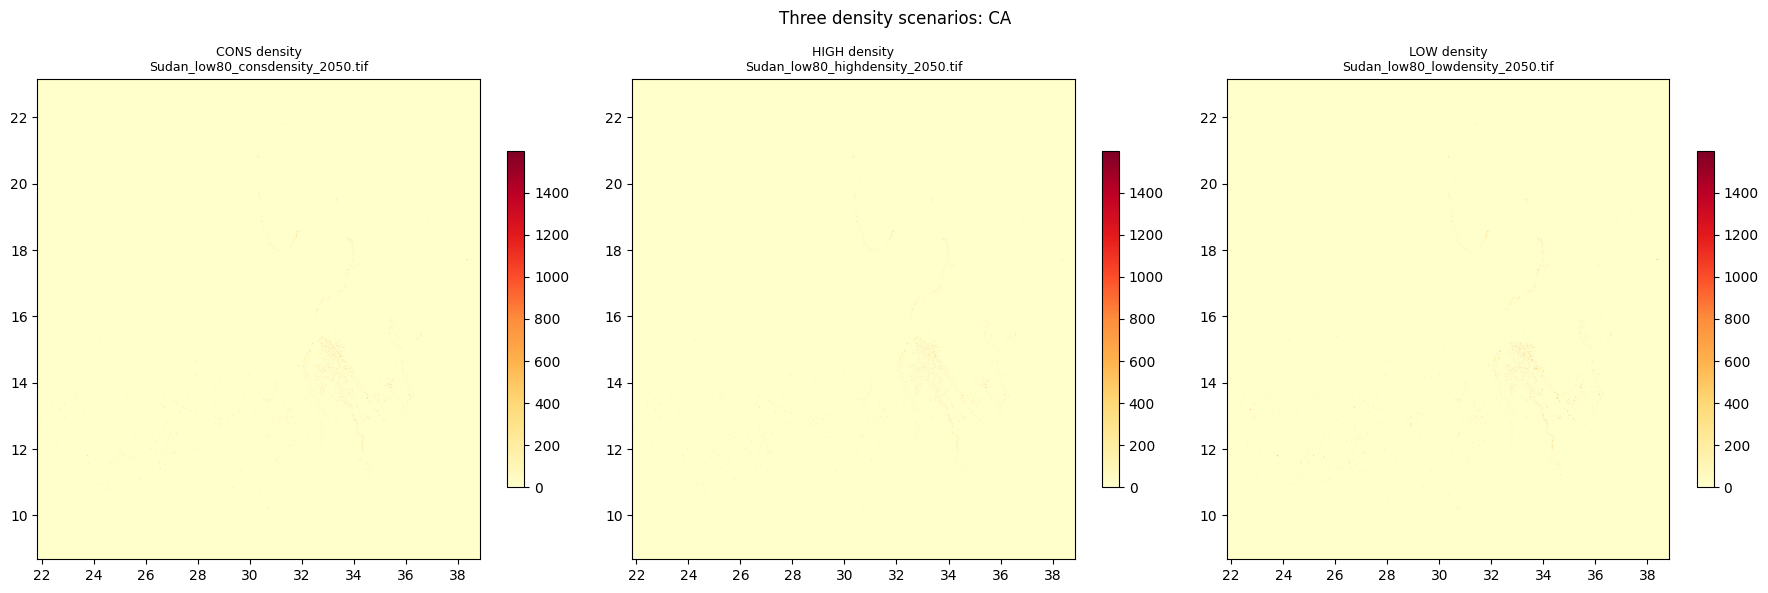

Saved: scenario_comparison.png


In [7]:
# Visualize: side-by-side map of high vs cons vs low for one country
import rasterio
import matplotlib.pyplot as plt
import numpy as np

if complete:
    folder_name = list(complete.keys())[0]
    scenarios = complete[folder_name]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for ax, (sc, fpath) in zip(axes, scenarios.items()):
        with rasterio.open(fpath) as src:
            data = src.read(1).astype(float)
            nodata = src.nodata
            if nodata is not None:
                data[data == nodata] = np.nan
            bounds = src.bounds
        
        im = ax.imshow(data, cmap='YlOrRd', aspect='auto',
                       extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
        ax.set_title(f'{sc.upper()} density\n{os.path.basename(fpath)[:40]}', fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.7)
    
    fig.suptitle(f'Three density scenarios: {folder_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig('scenario_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved: scenario_comparison.png')

In [8]:
# KEY QUESTION: what do pixel values represent?
# Is it 0/1 (binary: urban/non-urban)?
# Or a continuous density value?
# Or population count per pixel?

if complete:
    folder_name = list(complete.keys())[0]
    f_high = complete[folder_name]['high']
    
    with rasterio.open(f_high) as src:
        data = src.read(1)
        nodata = src.nodata
        res = src.res  # pixel size in degrees
        print(f'Pixel size: {res[0]:.6f} × {res[1]:.6f} degrees')
        print(f'≈ {res[0]*111:.2f} × {res[1]*111:.2f} km at equator')
    
    valid = data[data != nodata] if nodata is not None else data.flatten()
    print(f'\nValue distribution:')
    unique, counts = np.unique(valid, return_counts=True)
    print(f'  Unique values: {unique[:30]}')
    print(f'  Counts:        {counts[:30]}')
    print(f'  Total unique: {len(unique)}')
    
    if len(unique) <= 5:
        print('\n→ Looks like BINARY or CATEGORICAL raster (urban mask)')
    else:
        print('\n→ Looks like CONTINUOUS raster (density or population)')

Pixel size: 0.003333 × 0.003333 degrees
≈ 0.37 × 0.37 km at equator

Value distribution:
  Unique values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 12. 13. 14. 15. 16. 17. 20.
 21. 22. 23. 24. 25. 26. 28. 29. 30. 31. 33. 36.]
  Counts:        [22074761    21113     1015     1362     1177      736     1058      801
      835      493      940      470      204      949      302      373
      314      362      164      192      267      639      410      330
      240      184      199       99      303       93]
  Total unique: 1516

→ Looks like CONTINUOUS raster (density or population)


In [9]:
# CRITICAL: relationship between tif and shapefile
# The shapefile has polygon boundaries for each city
# The tif might be the RASTER version of the urban extent
# OR the tif might give additional info INSIDE the polygon

# Let's check: does the tif cover the whole country or just city footprints?
if tif_files:
    # Pick Guinea Ecuatorial (the example you gave)
    geq_tifs = [f for f in tif_files if 'Guinea' in f or 'GEQ' in f or 'Ecuatorial' in f]
    if geq_tifs:
        print('Guinea Ecuatorial tifs found:')
        for f in geq_tifs:
            print(f'  {os.path.basename(f)}')
        
        with rasterio.open(geq_tifs[0]) as src:
            print(f'\nBounds: {src.bounds}')
            print(f'CRS: {src.crs}')
    else:
        print('Guinea Ecuatorial tifs not found with that name — checking folder:')
        geq_tifs = [f for f in tif_files if 'GEQ' in os.path.dirname(f) or 
                    'Insular' in f or 'CA' in os.path.dirname(f)]
        for f in geq_tifs[:5]:
            print(f'  {os.path.relpath(f, BASE_DIR)}')

Guinea Ecuatorial tifs found:
  Guinea_Ecuatorial_low80_consdensity_2020.tif
  Guinea_Ecuatorial_low80_consdensity_2025.tif
  Guinea_Ecuatorial_low80_consdensity_2030.tif
  Guinea_Ecuatorial_low80_consdensity_2035.tif
  Guinea_Ecuatorial_low80_consdensity_2040.tif
  Guinea_Ecuatorial_low80_consdensity_2045.tif
  Guinea_Ecuatorial_low80_consdensity_2050.tif
  Guinea_Ecuatorial_low80_highdensity_2020.tif
  Guinea_Ecuatorial_low80_highdensity_2025.tif
  Guinea_Ecuatorial_low80_highdensity_2030.tif
  Guinea_Ecuatorial_low80_highdensity_2035.tif
  Guinea_Ecuatorial_low80_highdensity_2040.tif
  Guinea_Ecuatorial_low80_highdensity_2045.tif
  Guinea_Ecuatorial_low80_highdensity_2050.tif
  Guinea_Ecuatorial_low80_lowdensity_2020.tif
  Guinea_Ecuatorial_low80_lowdensity_2025.tif
  Guinea_Ecuatorial_low80_lowdensity_2030.tif
  Guinea_Ecuatorial_low80_lowdensity_2035.tif
  Guinea_Ecuatorial_low80_lowdensity_2040.tif
  Guinea_Ecuatorial_low80_lowdensity_2045.tif
  Guinea_Ecuatorial_low80_lowdensity

In [19]:
import pickle
for name in ["Network_urban_low_2050", "Network_urban_cons_2050", "Network_urban_high_2050"]:
    G = pickle.load(open(f"../output/{name}.pkl", "rb"))
    edf = G.get_edge_dataframe()
    print(name, "| Between50 max:", edf["Between50"].max() if "Between50" in edf.columns else "NOT FOUND")

Network_urban_low_2050 | Between50 max: 31031518.88235289
Network_urban_cons_2050 | Between50 max: 31031519.179127123
Network_urban_high_2050 | Between50 max: 31031519.248606984


In [20]:
import pickle
import numpy as np

names = {
    "baseline":   ("../output/Network_baseline.pkl",        "Between50"),
    "urban_low":  ("../output/Network_urban_low_2050.pkl",  "Between50"),
    "urban_cons": ("../output/Network_urban_cons_2050.pkl", "Between50"),
    "urban_high": ("../output/Network_urban_high_2050.pkl", "Between50"),
}

results = {}
for label, (path, attr) in names.items():
    G   = pickle.load(open(path, "rb"))
    edf = G.get_edge_dataframe()
    b   = edf[attr].values
    results[label] = b
    print(f"{label:15s}  max={b.max():>14.1f}  median={np.median(b[b>0]):>12.1f}  active={(b>0).sum():>5d}")

print()
low  = results["urban_low"]
cons = results["urban_cons"]
high = results["urban_high"]
diff_lc = np.abs(low - cons)
diff_lh = np.abs(low - high)
print(f"low vs cons: 完全相同的边 = {(diff_lc==0).sum()}/{len(low)}  最大差异 = {diff_lc.max():.4f}")
print(f"low vs high: 完全相同的边 = {(diff_lh==0).sum()}/{len(low)}  最大差异 = {diff_lh.max():.4f}")

# 看time列是否真的不同
G_low  = pickle.load(open("../output/Network_urban_low_2050.pkl",  "rb"))
G_high = pickle.load(open("../output/Network_urban_high_2050.pkl", "rb"))
edf_l  = G_low.get_edge_dataframe()
edf_h  = G_high.get_edge_dataframe()
print("\nedge列名:", [c for c in edf_l.columns])
time_cols = [c for c in edf_l.columns if "time" in c.lower()]
for tc in time_cols:
    if tc in edf_h.columns:
        diff = np.abs(edf_l[tc].values - edf_h[tc].values)
        print(f"time列 {tc:25s}: low vs high 最大差异={diff.max():.4f}, 不同边数={(diff>0.001).sum()}")

baseline         max=    21242112.0  median=         2.9  active= 4192
urban_low        max=    31031518.9  median=         1.9  active= 4765
urban_cons       max=    31031519.2  median=         2.1  active= 4719
urban_high       max=    31031519.2  median=         2.1  active= 4688

low vs cons: 完全相同的边 = 4432/9159  最大差异 = 29838.0616
low vs high: 完全相同的边 = 4401/9159  最大差异 = 2532.9204

edge列名: ['source', 'target', 'from', 'to', 'l', 'h', 'time', 'timeU', 'timeUCB', 'border', 'timeU_high2050', 'timeU_cons2050', 'timeU_lowd2050', 'Between', 'Between50']
time列 time                     : low vs high 最大差异=0.0000, 不同边数=0
time列 timeU                    : low vs high 最大差异=0.0000, 不同边数=0
time列 timeUCB                  : low vs high 最大差异=0.0000, 不同边数=0
time列 timeU_high2050           : low vs high 最大差异=0.0000, 不同边数=0
time列 timeU_cons2050           : low vs high 最大差异=0.0000, 不同边数=0
time列 timeU_lowd2050           : low vs high 最大差异=0.0000, 不同边数=0


In [16]:
import pandas as pd
edges = pd.read_csv("../input/AfricaNetworkEdges_withUrban.csv")
print([c for c in edges.columns if "time" in c.lower()])

['time', 'timeU', 'timeUCB', 'timeU_high2050', 'timeU_cons2050', 'timeU_lowd2050']


In [15]:
import pandas as pd
import numpy as np

edges = pd.read_csv("../input/AfricaNetworkEdges_withUrban.csv")
print(edges[["timeU_high2050","timeU_cons2050","timeU_lowd2050"]].describe())

diff_hl = np.abs(edges["timeU_high2050"] - edges["timeU_lowd2050"])
print(f"\nhigh vs low: 完全相同的边={( diff_hl==0).sum()}/{len(edges)}")
print(f"最大差异={diff_hl.max():.4f}")

       timeU_high2050  timeU_cons2050  timeU_lowd2050
count     9159.000000     9159.000000     9159.000000
mean        42.165548       42.328316       43.102815
std         69.607923       69.759384       70.195975
min          0.012288        0.012288        0.012288
25%          4.836634        4.837346        4.950975
50%         15.466753       15.487969       15.911910
75%         49.040239       49.818044       50.962319
max        856.875461      856.875461      856.875461

high vs low: 完全相同的边=4991/9159
最大差异=66.4626


In [ ]:
import pickle, numpy as np

G_low  = pickle.load(open("../output/Network_urban_low_2050.pkl",  "rb"))
G_cons = pickle.load(open("../output/Network_urban_cons_2050.pkl", "rb"))
G_high = pickle.load(open("../output/Network_urban_high_2050.pkl", "rb"))

b_low  = np.array(G_low.es["Between50"])
b_cons = np.array(G_cons.es["Between50"])
b_high = np.array(G_high.es["Between50"])

# 总拥堵压力（系统级指标）
print(f"总拥堵压力 (sum):")
print(f"  low:  {b_low.sum():>15.0f}")
print(f"  cons: {b_cons.sum():>15.0f}")
print(f"  high: {b_high.sum():>15.0f}")

# 拥堵集中度
def gini(x):
    x = np.sort(x[x>0])
    n = len(x)
    return (2*np.sum(np.arange(1,n+1)*x)/(n*x.sum())) - (n+1)/n

print(f"\n集中度 (Gini):")
print(f"  low:  {gini(b_low):.4f}")
print(f"  cons: {gini(b_cons):.4f}")
print(f"  high: {gini(b_high):.4f}")

# 分位数分布
print(f"\nP50 / P90 / P99 (非零边):")
for label, b in [("low",b_low),("cons",b_cons),("high",b_high)]:
    bp = b[b>0]
    print(f"  {label}: {np.percentile(bp,50):>10.1f} / {np.percentile(bp,90):>12.1f} / {np.percentile(bp,99):>14.1f}")

# 哪些边在scenario间差异最大
diff = b_low - b_high
top_diff_idx = np.argsort(np.abs(diff))[::-1][:5]
print(f"\nlow vs high 差异最大的5条边 (index, diff):")
for i in top_diff_idx:
    print(f"  edge {i}: low={b_low[i]:.0f}  high={b_high[i]:.0f}  diff={diff[i]:.0f}")

总拥堵压力 (sum):
  low:         33896128
  cons:        33955344
  high:        33946018

集中度 (Gini):
  low:  0.9992
  cons: 0.9991
  high: 0.9991

P50 / P90 / P99 (非零边):
  low:        1.9 /         49.8 /         1316.1
  cons:        2.1 /         58.8 /         1548.4
  high:        2.1 /         60.8 /         1869.5

low vs high 差异最大的5条边 (index, diff):
  edge 1644: low=6482  high=9015  diff=-2533
  edge 7679: low=951  high=2941  diff=-1991
  edge 75: low=2177  high=611  diff=1566
  edge 1647: low=382256  high=383556  diff=-1300
  edge 1603: low=1573  high=2768  diff=-1195


In [25]:
import pickle
import numpy as np

scenarios = {
    "baseline":  ("../output/Network_baseline.pkl",        "Between"),
    "pop2050":   ("../output/Network_baseline.pkl",        "Between50"),
    "low2050":   ("../output/Network_urban_low_2050.pkl",  "Between50"),
    "cons2050":  ("../output/Network_urban_cons_2050.pkl", "Between50"),
    "high2050":  ("../output/Network_urban_high_2050.pkl", "Between50"),
}

def gini(x):
    x = np.sort(x[x > 0])
    n = len(x)
    return (2 * np.sum(np.arange(1, n+1) * x) / (n * x.sum())) - (n+1)/n

print(f"{'scenario':12s}  {'active egdes':>8s}  {'sum':>14s}  {'max':>12s}  {'P99':>10s}  {'Gini':>6s}")
print("-" * 70)

for label, (path, attr) in scenarios.items():
    G = pickle.load(open(path, "rb"))
    b = np.array(G.es[attr], dtype=float)
    active = (b > 0).sum()
    print(f"{label:12s}  {active:>8d}  {b.sum():>14.0f}  {b.max():>12.0f}  "
          f"{np.percentile(b[b>0], 99):>10.0f}  {gini(b):>6.4f}")

scenario      active egdes             sum           max         P99    Gini
----------------------------------------------------------------------
baseline          4586        35017070       8440153        9640  0.9971
pop2050           4192        25418610      21242112        3859  0.9982
low2050           4765        33896128      31031519        1316  0.9992
cons2050          4719        33955344      31031519        1548  0.9991
high2050          4688        33946018      31031519        1870  0.9991


In [30]:
import pandas as pd
import numpy as np

edges = pd.read_csv("../input/AfricaNetworkEdges_withUrban.csv")

# 每条边的时间增量（相比纯城际baseline）
edges["delta_high"] = edges["timeU_high2050"] - edges["time"]
edges["delta_cons"] = edges["timeU_cons2050"] - edges["time"]
edges["delta_low"]  = edges["timeU_lowd2050"] - edges["time"]

# 三个scenario之间的差异
edges["diff_high_vs_low"] = edges["timeU_lowd2050"] - edges["timeU_high2050"]

print("=== 相比baseline(time)的时间增量 ===")
for col, label in [("delta_high","high"),("delta_cons","cons"),("delta_low","low")]:
    d = edges[col]
    affected = (d > 0.01).sum()
    print(f"{label}: 受影响边={affected}/9159  "
          f"mean增量={d.mean():.2f}min  max增量={d.max():.1f}min")

print("\n=== high vs low 的差异 ===")
d = edges["diff_high_vs_low"]
print(f"差异>0.1min的边: {(d>0.1).sum()}")
print(f"差异>1min的边:   {(d>1.0).sum()}")
print(f"最大差异: {d.max():.2f}min")
print(f"中位差异: {d.median():.4f}min")

print("\n=== 受影响最大的10条边 ===")
top = edges.nlargest(10, "diff_high_vs_low")[
    ["from","to","l","h","time","timeU_high2050","timeU_lowd2050","diff_high_vs_low"]
]
print(top.to_string())

=== 相比baseline(time)的时间增量 ===
high: 受影响边=5204/9159  mean增量=1.87min  max增量=49.5min
cons: 受影响边=4875/9159  mean增量=1.97min  max增量=66.8min
low: 受影响边=5100/9159  mean增量=2.49min  max增量=81.7min

=== high vs low 的差异 ===
差异>0.1min的边: 2973
差异>1min的边:   1516
最大差异: 52.89min
中位差异: 0.0000min

=== 受影响最大的10条边 ===
         from       to           l         h        time  timeU_high2050  timeU_lowd2050  diff_high_vs_low
6309  1095205  1298599   61.787069     trunk   61.787069       61.787069      114.676800         52.889731
1379     8587  1019598  101.193123  motorway   60.715874       60.715874       99.605784         38.889910
232      2484     8866   86.186370     trunk   86.186370      105.504007      141.167331         35.663324
3998  1059659     4669   56.387808     trunk   56.387808       56.387808       91.011900         34.624092
5066  1070531  1133538   88.782168   primary  133.173251      133.173251      166.404565         33.231314
565      3079  1223629   96.523744     trunk   96.523744     

In [32]:
import pandas as pd
import numpy as np

edges = pd.read_csv("../input/AfricaNetworkEdges_withUrban.csv")

# 反推原始time列隐含的平均速度
edges["implied_speed"] = edges["l"] / edges["time"] * 60  # km/h

print("原始time列隐含的速度分布（km/h）：")
print(edges.groupby("h")["implied_speed"].describe()[["mean","min","max"]].round(1))

原始time列隐含的速度分布（km/h）：
                mean    min    max
h                                 
added           15.0   15.0   15.0
motorway       100.0  100.0  100.0
motorway_link  100.0  100.0  100.0
primary         40.0   40.0   40.0
primary_link    40.0   40.0   40.0
trunk           60.0   60.0   60.0
trunk_link      60.0   60.0   60.0


In [38]:
import pickle, numpy as np

scenarios = {
    "baseline":  ("../output/Network_baseline.pkl",        "Between"),
    "pop2050":   ("../output/Network_baseline.pkl",        "Between50"),
    "low2050":   ("../output/Network_urban_low_2050.pkl",  "Between50"),
    "cons2050":  ("../output/Network_urban_cons_2050.pkl", "Between50"),
    "high2050":  ("../output/Network_urban_high_2050.pkl", "Between50"),
}

def gini(x):
    x = np.sort(x[x > 0])
    n = len(x)
    return (2 * np.sum(np.arange(1, n+1) * x) / (n * x.sum())) - (n+1)/n

print(f"{'scenario':12s}  {'active边':>8s}  {'sum':>14s}  {'max':>12s}  {'P99':>10s}  {'Gini':>6s}")
print("-" * 70)
for label, (path, attr) in scenarios.items():
    G = pickle.load(open(path, "rb"))
    b = np.array(G.es[attr], dtype=float)
    print(f"{label:12s}  {(b>0).sum():>8d}  {b.sum():>14.0f}  "
          f"{b.max():>12.0f}  {np.percentile(b[b>0],99):>10.0f}  {gini(b):>6.4f}")

scenario       active边             sum           max         P99    Gini
----------------------------------------------------------------------
baseline          4586        35017070       8440153        9640  0.9971
pop2050           4192        25418610      21242112        3859  0.9982
low2050           4298        25404156      21242112        3925  0.9982
cons2050          4274        25394988      21242112        3940  0.9983
high2050          4272        25401093      21242112        3941  0.9982


In [40]:
import pickle
GM = pickle.load(open("../output/GravityPairs_baseline.pkl", "rb"))
print(GM.columns.tolist())
print(GM[["GravM","GravM50"]].describe())

['from', 'to', 'GravM', 'GravM50']
              GravM       GravM50
count  2.500000e+04  2.500000e+04
mean   1.109016e+03  9.765539e+02
std    6.504755e+04  1.346156e+05
min    8.326824e-03  0.000000e+00
25%    1.602713e-02  0.000000e+00
50%    3.820339e-02  0.000000e+00
75%    1.574093e-01  6.670374e-02
max    8.422885e+06  2.124208e+07


In [2]:
import pandas as pd
nodes = pd.read_csv("../input/AfricaNetworkNodes.csv")
afp   = pd.read_csv("../input/Africapolis_2050.csv")
afp   = afp.rename(columns={"Agglomeration_ID":"name","Population_2050":"Pop2050"})
nodes = nodes.merge(afp, on="name", how="left")

missing = nodes[(nodes["Pop2015"]>0) & (nodes["Pop2050"].isna())]
print(f"2050消失的城市: {len(missing)}")
print(f"消失城市的2015总人口: {missing['Pop2015'].sum():,.0f}")
print(f"所有城市2015总人口:   {nodes['Pop2015'].sum():,.0f}")
print(f"占比: {missing['Pop2015'].sum()/nodes['Pop2015'].sum()*100:.1f}%")

2050消失的城市: 263
消失城市的2015总人口: 33,616,894
所有城市2015总人口:   460,684,735
占比: 7.3%


In [13]:
import pandas as pd
import numpy as np

nodes = pd.read_csv("../input/AfricaNetworkNodes.csv")
afp   = pd.read_csv("../input/Africapolis_2050.csv")
afp   = afp.rename(columns={"Agglomeration_ID":"name", "Population_2050":"Pop2050"})
nodes = nodes.merge(afp, on="name", how="left")

missing = nodes[(nodes["Pop2015"] > 0) & (nodes["Pop2050"].isna())].copy()

print("=== 消失城市的规模分布 ===")
bins = [0, 10000, 50000, 100000, 500000, np.inf]
labels = ["<1万", "1-5万", "5-10万", "10-50万", ">50万"]
missing["size_cat"] = pd.cut(missing["Pop2015"], bins=bins, labels=labels)
print(missing["size_cat"].value_counts().sort_index().to_string())

print("\n=== 消失城市按区域分布 ===")
print(missing.groupby("Region")["Pop2015"].agg(["count","sum"]).to_string())

print("\n=== 消失城市中最大的10个 ===")
print(missing.nlargest(10, "Pop2015")[["agglosName","Region","Pop2015"]].to_string())

=== 消失城市的规模分布 ===
size_cat
<1万         0
1-5万      104
5-10万      77
10-50万     72
>50万       10

=== 消失城市按区域分布 ===
         count       sum
Region                  
Central      5    207831
East        47  10716320
North      175  19677092
South       12   1000613
West        24   2015038

=== 消失城市中最大的10个 ===
     agglosName Region  Pop2015
197       Kisii   East  3407476
541       Asyut  North  1345668
582  al-Zaqaziq  North  1075066
214        Maua   East   848272
590       Tanta  North   755175
196       Bomet   East   753093
533   al-Bilina  North   701286
585   Mit Ghamr  North   523195
535      Akhmim  North   516789
208        Meru   East   515084


In [15]:
import pandas as pd

nodes = pd.read_csv("../input/AfricaNetworkNodes.csv")
afp   = pd.read_csv("../input/Africapolis_agglomeration_2025.csv")  # 新文件路径

# 方法1：用ID直接匹配
afp_renamed = afp.rename(columns={"Agglomeration_ID": "name", "Population_2050": "Pop2050"})
merged = nodes.merge(afp_renamed[["name","Pop2050"]], on="name", how="left")

matched   = merged["Pop2050"].notna() & (merged["Pop2050"] > 0)
unmatched = merged["Pop2050"].isna()
zero      = merged["Pop2050"] == 0

print(f"=== ID匹配结果 ===")
print(f"nodes总数:              {len(nodes)}")
print(f"有Pop2015的城市节点:    {(nodes['Pop2015']>0).sum()}")
print(f"匹配到Pop2050>0:        {matched.sum()}")
print(f"匹配到但Pop2050=0:      {zero.sum()}  ← 新数据里明确标为0")
print(f"完全没匹配上(ID不在新数据里): {unmatched.sum()}")

print(f"\n=== 没匹配上的城市节点（有Pop2015但ID不在新数据）===")
missing = merged[(nodes["Pop2015"]>0) & unmatched][["name","agglosName","ISO3","Pop2015"]]
print(f"数量: {len(missing)}")
print(missing.nlargest(10, "Pop2015")[["agglosName","ISO3","Pop2015"]].to_string())

print(f"\n=== Pop2050明确为0的城市（可能是合并）===")
zeros = merged[(nodes["Pop2015"]>0) & zero][["name","agglosName","ISO3","Pop2015"]]
print(f"数量: {len(zeros)}")
print(zeros.nlargest(10, "Pop2015")[["agglosName","ISO3","Pop2015"]].to_string())

=== ID匹配结果 ===
nodes总数:              7361
有Pop2015的城市节点:    2162
匹配到Pop2050>0:        1619
匹配到但Pop2050=0:      280  ← 新数据里明确标为0
完全没匹配上(ID不在新数据里): 5462

=== 没匹配上的城市节点（有Pop2015但ID不在新数据）===
数量: 263
     agglosName ISO3  Pop2015
197       Kisii  KEN  3407476
541       Asyut  EGY  1345668
582  al-Zaqaziq  EGY  1075066
214        Maua  KEN   848272
590       Tanta  EGY   755175
196       Bomet  KEN   753093
533   al-Bilina  EGY   701286
585   Mit Ghamr  EGY   523195
535      Akhmim  EGY   516789
208        Meru  KEN   515084

=== Pop2050明确为0的城市（可能是合并）===
数量: 280
         agglosName ISO3  Pop2015
217          Kisumu  KEN  5040159
198            Embu  KEN  2046897
267   Port Harcourt  NGA  1845232
276             Aba  NGA  1687158
43       Soshanguve  ZAF  1293433
309           Enugu  NGA   905042
26   Evaton Central  ZAF   784481
347        Abeokuta  NGA   747542
316         Ikorodu  NGA   732343
173         Ruhango  RWA   599923


In [16]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

nodes = pd.read_csv("../input/AfricaNetworkNodes.csv")
afp   = pd.read_csv("../input/Africapolis_agglomeration_2025.csv")

# 只对263个没匹配上的城市节点做坐标匹配
afp_renamed = afp.rename(columns={"Agglomeration_ID":"name","Population_2050":"Pop2050"})
merged = nodes.merge(afp_renamed[["name","Pop2050"]], on="name", how="left")
unmatched_nodes = nodes[(nodes["Pop2015"]>0) & merged["Pop2050"].isna()].copy()

# 新数据里有坐标的城市
afp_valid = afp[afp["Longitude"].notna() & afp["Latitude"].notna()].copy()

# KD-tree最近邻匹配
tree = cKDTree(afp_valid[["Longitude","Latitude"]].values)
dists, idxs = tree.query(unmatched_nodes[["x","y"]].values, k=1)

unmatched_nodes["matched_afp_id"]   = afp_valid.iloc[idxs]["Agglomeration_ID"].values
unmatched_nodes["matched_afp_name"] = afp_valid.iloc[idxs]["Agglomeration_Name"].values
unmatched_nodes["matched_pop2050"]  = afp_valid.iloc[idxs]["Population_2050"].values
unmatched_nodes["dist_deg"]         = dists

print("=== 263个没匹配上城市的坐标匹配结果 ===")
print(f"距离<0.1度的匹配: {(dists<0.1).sum()}")
print(f"距离<0.5度的匹配: {(dists<0.5).sum()}")
print(f"距离>1度的匹配:   {(dists>1.0).sum()}  ← 这些可能真的没有对应城市")

print("\n=== 最大城市的匹配情况 ===")
top = unmatched_nodes.nlargest(15, "Pop2015")[
    ["agglosName","ISO3","Pop2015","matched_afp_name","matched_pop2050","dist_deg"]
]
print(top.to_string())

=== 263个没匹配上城市的坐标匹配结果 ===
距离<0.1度的匹配: 182
距离<0.5度的匹配: 263
距离>1度的匹配:   0  ← 这些可能真的没有对应城市

=== 最大城市的匹配情况 ===
        agglosName ISO3  Pop2015        matched_afp_name  matched_pop2050  dist_deg
197          Kisii  KEN  3407476                Kilgoris             0.00  0.342838
541          Asyut  EGY  1345668            al-Tawabiyya         13112.85  0.081615
582     al-Zaqaziq  EGY  1075066                  Farsis         11366.21  0.094430
214           Maua  KEN   848272                   Kinna         16421.06  0.256780
590          Tanta  EGY   755175             al-Ragdiyya         21975.57  0.078447
196          Bomet  KEN   753093                Kilgoris             0.00  0.372005
533      al-Bilina  EGY   701286  al-Awamir & Bani Birza         18747.81  0.134729
585      Mit Ghamr  EGY   523195        Tafhanat al-Izab         27925.34  0.078549
535         Akhmim  EGY   516789   Gazirat al-Shuraniyya             0.00  0.060877
208           Meru  KEN   515084                    E

In [18]:
import pickle
import numpy as np

G_base = pickle.load(open("../output/Network_baseline.pkl", "rb"))
G_low  = pickle.load(open("../output/Network_urban_low_2050.pkl", "rb"))
G_high = pickle.load(open("../output/Network_urban_high_2050.pkl", "rb"))

# 找Lagos→Abidjan的路径
vdf = G_base.get_vertex_dataframe()
name2idx = {r["agglosName"]: i for i, r in vdf.iterrows() if r["agglosName"]}

oi = name2idx["Lagos"]
di = name2idx["Abidjan"]

path = G_base.get_shortest_paths(oi, di, weights=G_base.es["l"], output="epath")[0]

print(f"路径边数: {len(path)}")
print(f"\n{'边':>6}  {'base_B50':>12}  {'low_B50':>12}  {'high_B50':>12}  {'diff_l_h':>10}")
for eid in path:
    b_base = G_base.es[eid]["Between50"]
    b_low  = G_low.es[eid]["Between50"]
    b_high = G_high.es[eid]["Between50"]
    print(f"{eid:>6}  {b_base:>12.0f}  {b_low:>12.0f}  {b_high:>12.0f}  {b_low-b_high:>10.0f}")

路径边数: 44

     边      base_B50       low_B50      high_B50    diff_l_h
   785          1040          1036          1036          -0
   776          1040          1036          1036          -0
   777          1040          1036          1036          -0
  8021          1040          1036          1036          -0
  8022          1040          1036          1036          -0
  8930          1040          1036          1036          -0
  4267          1040          1036          1036          -0
  4260          1040          1036          1036          -0
  4261             0          1036          1036          -0
  4263             0          1036          1036          -0
  4264          1040          1036          1036          -0
  7448           172             0             0           0
  7447           268           272           272          -0
  8236           268           272           272          -0
  5345           268           272           272          -0
  5344        

In [19]:
# 试几个城内或跨城路径
test_pairs = [
    ("Lagos", "Ibadan"),       # 都在尼日利亚西南，中间穿城区
    ("Kano", "Kaduna"),        # 尼日利亚北部城市间
    ("Nairobi", "Mombasa"),    # 肯尼亚，穿越内罗毕郊区
    ("Cairo", "Alexandria"),   # 埃及，两大城市间
    ("Abidjan", "Kumasi"),     # 西非跨境
]

for orig, dest in test_pairs:
    oi = name2idx.get(orig)
    di = name2idx.get(dest)
    if oi is None or di is None:
        print(f"{orig}→{dest}: 城市未找到")
        continue
    path = G_base.get_shortest_paths(oi, di, weights=G_base.es["l"], output="epath")[0]
    b_low  = np.array([G_low.es[e]["Between50"]  for e in path])
    b_high = np.array([G_high.es[e]["Between50"] for e in path])
    diff = np.abs(b_low - b_high)
    print(f"{orig}→{dest}: {len(path)}条边  max_diff={diff.max():.0f}  "
          f"edges_with_diff={(diff>1).sum()}")

Lagos→Ibadan: 8条边  max_diff=60  edges_with_diff=4
Kano→Kaduna: 12条边  max_diff=0  edges_with_diff=0
Nairobi→Mombasa: 11条边  max_diff=15  edges_with_diff=2
Cairo→Alexandria: 18条边  max_diff=159  edges_with_diff=18
Abidjan→Kumasi: 6条边  max_diff=0  edges_with_diff=0
